<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/Voronoi_Power_Diagram_View.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
"""
Arbitrarily-Nested Voronoi Power Diagram (Laguerre Diagram)
Updated:
- Labels centered on cell polygon centroids
- Area-constrained (capacity-constrained) partitioning by iteratively adjusting weights
- Optional Lloyd relaxation for nicer geometry
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

Point = np.ndarray
Poly = List[Point]


@dataclass(frozen=True)
class DiagramConfig:
    seed: int = 0
    radius: float = 1.0
    padding: float = 0.25
    top_jitter: float = 0.04
    child_jitter: float = 0.02
    figsize: Tuple[int, int] = (8, 8)

    # Weight scaling fallback (still used as initial weights)
    top_weight_scale: Optional[float] = None
    child_weight_scale: Optional[float] = None

    # Optional centroidal relaxation (positions)
    lloyd_iters: int = 3

    # Area-constrained partitioning (weights -> target areas)
    area_constrained: bool = True
    area_iters: int = 100
    area_lr: float = 0.25  # learning rate for weight updates (tune if needed)
    area_tol: float = 1e-3  # relative mean area error stopping condition


class PolygonOps:
    @staticmethod
    def bbox(xmin: float, xmax: float, ymin: float, ymax: float) -> Poly:
        return [
            np.array([xmin, ymin], float),
            np.array([xmax, ymin], float),
            np.array([xmax, ymax], float),
            np.array([xmin, ymax], float),
        ]

    @staticmethod
    def close(poly: Poly) -> np.ndarray:
        arr = np.asarray(poly, float)
        if arr.size == 0:
            return arr
        return np.vstack([arr, arr[0]])

    @staticmethod
    def clip_halfplane(poly: Poly, n: Point, c: float, eps: float = 1e-9) -> Poly:
        if not poly:
            return []

        def inside(x: Point) -> bool:
            return float(n @ x) <= c + eps

        def intersect(a: Point, b: Point) -> Point:
            ab = b - a
            denom = float(n @ ab)
            if abs(denom) < 1e-15:
                return a.copy()
            t = (c - float(n @ a)) / denom
            return a + np.clip(t, 0.0, 1.0) * ab

        out: Poly = []
        prev, prev_in = poly[-1], inside(poly[-1])

        for cur in poly:
            cur_in = inside(cur)
            if cur_in != prev_in:
                out.append(intersect(prev, cur))
            if cur_in:
                out.append(cur)
            prev, prev_in = cur, cur_in

        return PolygonOps._dedup(out)

    @staticmethod
    def _dedup(poly: Poly, tol: float = 1e-10) -> Poly:
        if not poly:
            return []
        out: Poly = [poly[0]]
        for p in poly[1:]:
            if np.linalg.norm(p - out[-1]) > tol:
                out.append(p)
        if len(out) > 1 and np.linalg.norm(out[0] - out[-1]) < tol:
            out.pop()
        return out

    @staticmethod
    def polygon_area(poly: Poly) -> float:
        if poly is None or len(poly) < 3:
            return 0.0
        arr = np.asarray(poly, float)
        x = arr[:, 0]
        y = arr[:, 1]
        return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

    @staticmethod
    def polygon_centroid(poly: Poly) -> Point:
        if not poly:
            return np.zeros(2)
        arr = np.asarray(poly, float)
        if len(arr) < 3:
            return np.mean(arr, axis=0)
        A = PolygonOps.polygon_area(arr)
        if abs(A) < 1e-12:
            return np.mean(arr, axis=0)

        x = arr[:, 0]
        y = arr[:, 1]
        cross = x * np.roll(y, -1) - np.roll(x, -1) * y
        cx = (1.0 / (6.0 * A)) * np.sum((x + np.roll(x, -1)) * cross)
        cy = (1.0 / (6.0 * A)) * np.sum((y + np.roll(y, -1)) * cross)
        return np.array([float(cx), float(cy)], float)

    @staticmethod
    def poly_diag(poly: Poly) -> float:
        if not poly:
            return 0.0
        arr = np.asarray(poly, float)
        xmin = float(np.min(arr[:, 0]))
        xmax = float(np.max(arr[:, 0]))
        ymin = float(np.min(arr[:, 1]))
        ymax = float(np.max(arr[:, 1]))
        return math.hypot(xmax - xmin, ymax - ymin)


@dataclass
class Node:
    label: str
    weight: float
    children: Dict[str, "Node"] = field(default_factory=dict)


class HierarchyParser:
    @staticmethod
    def _make_node(label: str, obj: Any) -> Node:
        if isinstance(obj, dict):
            weight = float(obj.get("weight", 0.0))
            children_raw = obj.get("children", {}) or {}
            children = {
                k: HierarchyParser._make_node(k, v)
                for k, v in children_raw.items()
            } if isinstance(children_raw, dict) else {}
            return Node(label, weight, children)
        return Node(label, float(obj), {})

    @staticmethod
    def parse(tree: Dict[str, Any]) -> Dict[str, Node]:
        return {k: HierarchyParser._make_node(k, v) for k, v in tree.items()}


@dataclass
class Site:
    # mutable: we update p (Lloyd) and w (area constraints)
    label: str
    p: Point
    w: float


class PowerDiagram:
    def __init__(self, ops: PolygonOps):
        self.ops = ops

    @staticmethod
    def auto_scale(weights: np.ndarray, length_scale: float) -> float:
        span = float(np.ptp(weights)) if len(weights) > 1 else 1.0
        return (length_scale ** 2) / (span + 1e-9)

    @staticmethod
    def _halfplane(a: Site, b: Site) -> Tuple[Point, float]:
        n = (b.p - a.p).astype(float)
        c = 0.5 * (float(b.p @ b.p) - float(a.p @ a.p) + a.w - b.w)
        return n, c

    def cell(self, s: Site, sites: List[Site], domain: Poly) -> Poly:
        poly = [np.array(v, float) for v in domain]
        for t in sites:
            if t is s:
                continue
            n, c = self._halfplane(s, t)
            poly = self.ops.clip_halfplane(poly, n, c)
            if not poly:
                break
        return poly


class Plotter:
    def __init__(self, cfg: DiagramConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self.ops = PolygonOps()
        self.pd = PowerDiagram(self.ops)

    # --- requirement #1: propagate weights upward ---
    @staticmethod
    def _propagate_weights_node(node: Node) -> float:
        if not node.children:
            return node.weight
        total = 0.0
        for ch in node.children.values():
            total += Plotter._propagate_weights_node(ch)
        node.weight = float(total)
        return node.weight

    def _propagate_weights(self, roots: Dict[str, Node]) -> None:
        for node in roots.values():
            Plotter._propagate_weights_node(node)

    def plot(self, hierarchy: Dict[str, Any]) -> None:
        roots = HierarchyParser.parse(hierarchy)
        self._propagate_weights(roots)

        xmin = -self.cfg.radius - self.cfg.padding
        xmax = self.cfg.radius + self.cfg.padding
        ymin = -self.cfg.radius - self.cfg.padding
        ymax = self.cfg.radius + self.cfg.padding
        bbox_poly = self.ops.bbox(xmin, xmax, ymin, ymax)

        fig, ax = plt.subplots(figsize=self.cfg.figsize)

        top_nodes = list(roots.values())
        # initial ring layout; weights are initial guesses (area constraint will refine)
        top_sites = self._layout_level(
            top_nodes, np.zeros(2), self.cfg.radius, self.cfg.top_jitter, self.cfg.top_weight_scale
        )

        top_cells = self._solve_level(
            sites=top_sites,
            nodes=top_nodes,
            domain=bbox_poly,
        )

        self._draw_cells(ax, top_sites, top_cells, alpha=0.25, lw=2.0)
        self._draw_labels_centered(ax, top_sites, top_cells, fontsize=9)

        for node in top_nodes:
            poly = top_cells.get(node.label, [])
            if poly and len(poly) >= 3:
                self._render_node(ax, node, poly, depth=1)

        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title("Arbitrarily-Nested Area-Constrained Power Diagram")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()

    def _render_node(self, ax, node: Node, parent_poly: Poly, depth: int) -> None:
        if not node.children:
            return

        children = list(node.children.values())
        center = self.ops.polygon_centroid(parent_poly)

        # child length from parent polygon size
        parent_diag = self.ops.poly_diag(parent_poly)
        length = max(1e-6, 0.35 * parent_diag)

        sites = self._layout_level(
            children, center, length, self.cfg.child_jitter, self.cfg.child_weight_scale
        )

        cells = self._solve_level(
            sites=sites,
            nodes=children,
            domain=parent_poly,
        )

        self._draw_cells(ax, sites, cells, alpha=0.35, lw=1.2)
        self._draw_labels_centered(ax, sites, cells, fontsize=8)

        for child in children:
            poly = cells.get(child.label, [])
            if poly and len(poly) >= 3:
                self._render_node(ax, child, poly, depth + 1)

    def _layout_level(
        self,
        nodes: List[Node],
        center: Point,
        length: float,
        jitter: float,
        weight_scale: Optional[float],
    ) -> List[Site]:
        labels = [n.label for n in nodes]
        raw_weights = np.array([n.weight for n in nodes], float)

        scale = weight_scale or self.pd.auto_scale(raw_weights, max(length, 1e-6))
        # initial effective weights (will be refined if area_constrained)
        w0 = raw_weights * scale

        if len(nodes) > 1:
            ang = np.linspace(0, 2 * math.pi, len(nodes), endpoint=False)
        else:
            ang = np.array([0.0])

        pts = np.c_[np.cos(ang), np.sin(ang)] * length + center
        pts += self.rng.normal(0.0, jitter, size=pts.shape)

        return [Site(labels[i], pts[i].astype(float), float(w0[i])) for i in range(len(nodes))]

    def _solve_level(self, sites: List[Site], nodes: List[Node], domain: Poly) -> Dict[str, Poly]:
        """
        Compute a (possibly area-constrained) power diagram inside `domain`.

        Targets: areas proportional to `nodes[i].weight`.
        Method: iteratively adjust the sites' effective weights w to match target areas.
        Optional: Lloyd relaxation on positions.
        """
        # target areas
        domain_area = abs(self.ops.polygon_area(domain))
        raw = np.array([n.weight for n in nodes], float)
        if np.all(raw <= 0):
            # if all zero/negative, fall back to equal areas
            raw = np.ones_like(raw)
        raw = np.maximum(raw, 0.0)
        raw_sum = float(raw.sum()) if raw.size else 1.0
        target_areas = (raw / raw_sum) * domain_area

        # convenience lookups
        label_to_idx = {nodes[i].label: i for i in range(len(nodes))}

        def compute_cells() -> Dict[str, Poly]:
            return {s.label: self.pd.cell(s, sites, domain) for s in sites}

        def areas_from_cells(cells: Dict[str, Poly]) -> np.ndarray:
            a = np.zeros(len(nodes), float)
            for lbl, poly in cells.items():
                i = label_to_idx.get(lbl)
                if i is None:
                    continue
                a[i] = abs(self.ops.polygon_area(poly))
            return a

        # optional: a few Lloyd steps (makes shapes nicer and reduces clipping bias)
        for _ in range(max(0, int(self.cfg.lloyd_iters))):
            cells = compute_cells()
            for s in sites:
                poly = cells.get(s.label, [])
                if poly and len(poly) >= 3:
                    s.p = self.ops.polygon_centroid(poly)

        # area-constrained weight adjustment
        if self.cfg.area_constrained and len(sites) > 1:
            # normalize learning rate to domain scale so it isn't wildly sensitive
            diag = max(1e-6, self.ops.poly_diag(domain))
            w_step_scale = (diag * diag) / max(domain_area, 1e-9)

            for _ in range(max(1, int(self.cfg.area_iters))):
                cells = compute_cells()
                cur_areas = areas_from_cells(cells)

                # relative mean error
                rel_err = float(np.mean(np.abs(cur_areas - target_areas) / (target_areas + 1e-9)))
                if rel_err < self.cfg.area_tol:
                    break

                # update weights: increasing w expands region, decreasing shrinks
                # delta_w ∝ (target - current)
                delta = (target_areas - cur_areas) * (self.cfg.area_lr * w_step_scale)

                # apply updates
                for s in sites:
                    i = label_to_idx[s.label]
                    s.w = float(s.w + delta[i])

        # final cells
        return compute_cells()

    def _draw_cells(self, ax, sites: List[Site], cells: Dict[str, Poly], *, alpha: float, lw: float) -> None:
        for s in sites:
            poly = cells.get(s.label, [])
            if len(poly) < 3:
                continue
            ring = self.ops.close(poly)
            ax.fill(ring[:, 0], ring[:, 1], alpha=alpha)
            ax.plot(ring[:, 0], ring[:, 1], linewidth=lw)

    def _draw_labels_centered(self, ax, sites: List[Site], cells: Dict[str, Poly], fontsize: int = 9) -> None:
        """
        Requirement: assign/position labels based on centroids of associated polygons.
        Labels are centered exactly on the centroid (no offset).
        """
        for s in sites:
            poly = cells.get(s.label, [])
            if poly and len(poly) >= 3:
                c = self.ops.polygon_centroid(poly)
            else:
                c = s.p
            ax.scatter([c[0]], [c[1]], s=18)
            ax.text(
                c[0],
                c[1],
                s.label,
                fontsize=fontsize,
                ha="center",
                va="center",
            )

# Tests

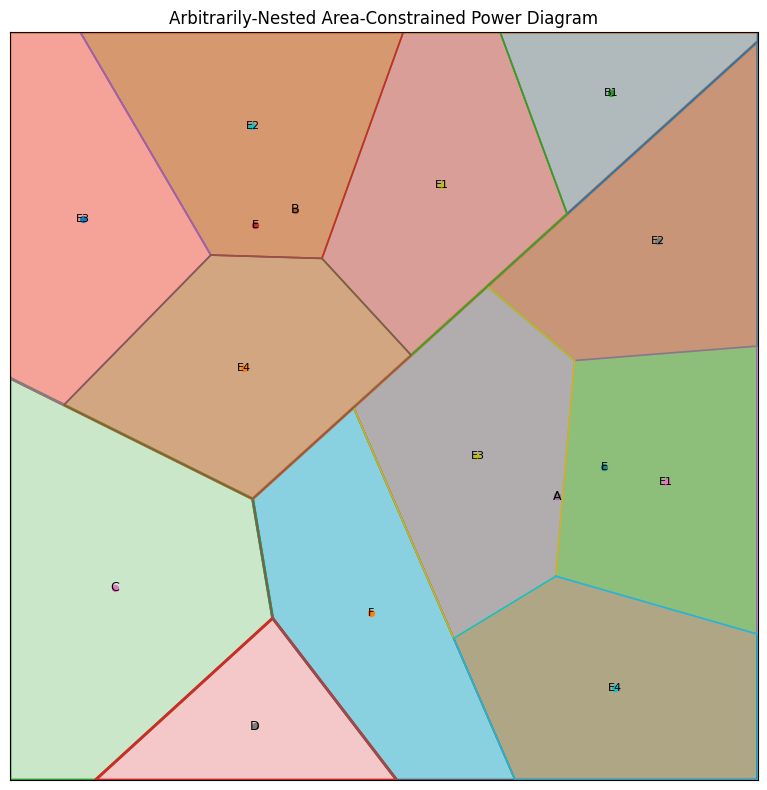

In [49]:

nested = {
    "A": {"children": {
        "E": {"children": {"E1": 1, "E2": 1, "E3": 1, "E4": 1}},
        "F": 1,
    }},
    "B": {"children": {
        "B1": 0.5,
        "E": {"children": {"E1": 1, "E2": 1, "E3": 1, "E4": 1}},
    }},
    "C": 1.5,
    "D": 0.5,
}

Plotter(DiagramConfig()).plot(nested)